In [1]:
import os
os.getcwd()

'c:\\Users\\Asus TUF Gaming A15\\Documents\\GitHub\\RM'

Current File Working :  Ses01F_impro01_F000.wav
Current File Working :  Ses01F_impro01_F001.wav
Current File Working :  Ses01F_impro01_F002.wav
Current File Working :  Ses01F_impro01_F003.wav
Current File Working :  Ses01F_impro01_F004.wav
Current File Working :  Ses01F_impro01_F005.wav
Current File Working :  Ses01F_impro01_F006.wav
Current File Working :  Ses01F_impro01_F007.wav
Current File Working :  Ses01F_impro01_F008.wav
Current File Working :  Ses01F_impro01_F009.wav
Current File Working :  Ses01F_impro01_F010.wav
Current File Working :  Ses01F_impro01_F011.wav
Current File Working :  Ses01F_impro01_F012.wav
Current File Working :  Ses01F_impro01_F013.wav
Current File Working :  Ses01F_impro01_F014.wav
Current File Working :  Ses01F_impro01_F015.wav
Current File Working :  Ses01F_impro01_M000.wav
Current File Working :  Ses01F_impro01_M001.wav
Current File Working :  Ses01F_impro01_M002.wav
Current File Working :  Ses01F_impro01_M003.wav
Current File Working :  Ses01F_impro01_M

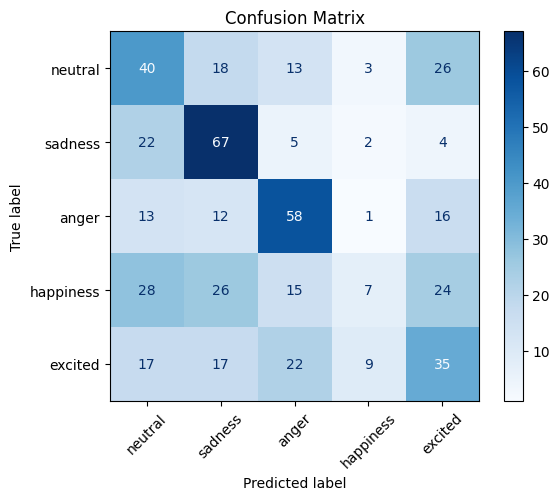

In [2]:
import torch,random
from torch import nn, optim
from collections import defaultdict
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def Create_Loader(dataset,batch_size):
    """
    This Function is for 
    """
    
    MIN_TEST_PER_CLASS = 100

    class_indices = defaultdict(list)
    for i in range(len(dataset)):
        _, y = dataset[i]
        if torch.is_tensor(y):
            y = y.item()
        class_indices[y].append(i)

    train_idx, test_idx = [], []
    for y, idxs in class_indices.items():
        if len(idxs) < MIN_TEST_PER_CLASS:
            raise ValueError(f"class {y} has only {len(idxs)} samples")
        random.shuffle(idxs)
        test_idx += idxs[:MIN_TEST_PER_CLASS]
        train_idx += idxs[MIN_TEST_PER_CLASS:]

    train_dataset = Subset(dataset, train_idx)
    test_dataset  = Subset(dataset, test_idx)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader,test_loader

def train_model(parameter,num_epochs,device,train_loader):

    vit_model = parameter
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(vit_model.parameters(), lr=1e-4)

    for epoch in range(num_epochs):
        vit_model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            # print(X_batch.shape)
            outputs = vit_model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

    return vit_model

def test_model(model,test_loader,device,emotion_map):

    vit_model = model
    vit_model.eval()  # set model to evaluation mode

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:  # use test_loader instead of train_loader
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = vit_model(X_batch)
            _, preds = torch.max(outputs, 1)

            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    # Concatenate all batches
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    # Convert to numpy
    y_true = all_labels.cpu().numpy()
    y_pred = all_preds.cpu().numpy()

    # Unique labels in test set
    unique_labels = sorted(torch.unique(all_labels).tolist())

    # Safe mapping
    all_emotions = {v: k for k, v in emotion_map.items()}
    # all_emotions = {0:'Angry', 1:'Happy', 2:'Sad', 3:'Neutral', 4:'Frustration'}
    display_labels = [all_emotions[i] if i in all_emotions else f"Unknown({i})" for i in unique_labels]

    # Classification report
    report = classification_report(
        y_true,
        y_pred,
        labels=unique_labels,
        target_names=display_labels
    )
    print("Classification Report - Test Set")
    print(report)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

path = r"C:\Coding\IEMOCAP\IEMOCAP\Cleaned"

"""

Class distribution:
Class 0 neutral : 1768
Class 1 frustration : 2874
Class 2 sadness : 1253
Class 3 surprise : 125
Class 4 anger : 1284
Class 5 happiness : 708
Class 6 excited : 1883
Class 7 fear : 105
Class 8 disgust : 3
Class 9 other : 36

"""

emotion_map = {
    "neutral":0,
    "sadness":1,
    "anger":2,
    "happiness":3,
    "excitement":4,
    "excited":4
}

"""
Available

FrontEnd
|- Leaf.preprocess
|   |- from FrontEnd import Leaf
|- Mel.preprocess
|   |- from FrontEnd import Mel
|- Scatter.preprocess
    |- from FrontEnd import Scatter

Model
|- VitCnnGlobal.Vit
|   |- from Model import VitCnnGlobal
|- VitCnnLocal.Vit
|   |- from Model import VitCnnLocal
|- VitGlobal.Vit
|   |- from Model import VitGlobal
|- VitLocal.Vit
|   |- from Model import VitLocal

"""



"""
------------------ Replace Front End Here ------------------
"""

from FrontEnd import Scatter
dataset = Scatter.preprocess(mapping=emotion_map,path=path)

"""
-------------------------------------------------------------
"""

train_loader,test_loader = Create_Loader(dataset,batch_size=32)

device = "cuda" if torch.cuda.is_available() else "cpu"
num_epochs = 20

"""
------------------ Replace Model Here ------------------
"""

from Model import VitGlobal
vit_model = VitGlobal.ViT(
    image_size=(64, 128),
    patch_size=(8, 8),
    num_classes=len(emotion_map),
    dim=256,
    depth=6,
    heads=8,
    dim_head=64,
    mlp_dim=1024,
    channels=1,
    dropout=0.1,
    emb_dropout=0.1
).to(device)

"""
-------------------------------------------------------------
"""

Model = train_model(parameter=vit_model,num_epochs=num_epochs,device=device,train_loader=train_loader)

test_model(model=Model,test_loader=test_loader,device=device,emotion_map=emotion_map)